<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/calculateur_cosmologique_ned_wright.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calculateur cosmologique interactif — d'apres Ned Wright

Ce notebook est une transposition en **Python 3 / Colab** du script en ligne de commande
`CC.py` de **Edward L. (Ned) Wright** (UCLA), version « batch » de son
[Cosmology Calculator](https://www.astro.ucla.edu/~wright/CosmoCalc.html)
(reference : Wright 2006, *PASP*, 118, 1711).

Le script original etait ecrit en **Python 2**. Ici on garde **exactement la meme
physique et le meme schema numerique**, mais on ajoute ce qu'un notebook permet :
des explications, des validations, et surtout **des figures**.

---

## Sommaire

| Partie | Contenu |
|---|---|
| **1** | Les parametres du modele : $z$, $H_0$, $\Omega_M$, $\Omega_\Lambda$, $\Omega_R$, $\Omega_k$ |
| **2** | Les equations : Friedmann, les integrales, les distances |
| **3–5** | Le code : constantes, fonction de calcul, affichage |
| **6** | Formulaire interactif (curseurs) |
| **7** | Validation contre solutions analytiques |
| **8** | Tableaux |
| **9** | **Galerie de figures** — le coeur pedagogique |
| **10–11** | Applications pratiques, fidelite au script original |

---

## Ce que le programme calcule

A partir de **quatre nombres** — $z$, $H_0$, $\Omega_M$, $\Omega_\Lambda$ — il fournit :
l'age de l'Univers aujourd'hui et au decalage $z$, le temps de trajet de la lumiere,
les trois distances cosmologiques ($D_C$, $D_A$, $D_L$), l'echelle spatiale en kpc/arcsec,
le volume comobile et le module de distance.

## Ce qu'il ne fait **pas** (limites a garder en tete)

- Modele **FLRW** strictement homogene et isotrope : aucune structure locale,
  aucun effet de lentille, aucune vitesse particuliere.
- L'energie noire est une **constante cosmologique pure** ($w = -1$, constante).
  Pas de $w(a)$, pas de quintessence.
- Le rayonnement est fixe a $\Omega_R = 4{,}165\times10^{-5}/h^2$, ce qui suppose
  $T_0 = 2{,}72528$ K et **3 especes de neutrinos sans masse**. Approximation doublement
  fausse : les neutrinos ont une masse (ils deviennent non relativistes a bas $z$), et
  au-dela de $z \sim 10^9$ le nombre de degres de liberte relativistes change.
- Integration numerique par **regle du point milieu**, $n = 1000$ pas (voir la
  section 7 pour l'etude de convergence).
- **Aucune barre d'erreur** n'est propagee : le resultat est aussi precis que les
  parametres que vous entrez, ni plus ni moins.
- Pour un objet proche ($z \lesssim 0{,}01$), la vitesse propre domine le flot de
  Hubble : le resultat n'a alors **aucun sens physique**.

---
# 1. Les parametres du modele

Cette section repond a une question simple : **que signifient les quatre nombres
qu'on entre dans le calculateur ?**

---

## 1.1 Le decalage spectral $z$ (*redshift*)

### Definition — c'est une mesure, pas un modele

Le decalage spectral est defini **uniquement** a partir de longueurs d'onde :

$$\boxed{\;1 + z \;=\; \frac{\lambda_{\text{observee}}}{\lambda_{\text{emise}}}\;}
\qquad\text{soit}\qquad
z = \frac{\lambda_{\text{obs}} - \lambda_{\text{em}}}{\lambda_{\text{em}}}$$

C'est une **grandeur purement observationnelle** : on identifie une raie spectrale
connue (H$\alpha$ a 6562,8 Å, le doublet Ca II H&K, Lyman-$\alpha$ a 1215,7 Å…), on
mesure ou elle est tombee, on fait le rapport. Aucune cosmologie n'intervient a ce stade.

$z > 0$ : decalage vers le rouge (*redshift*). $z < 0$ : vers le bleu (*blueshift*) —
c'est le cas de M31, qui se rapproche de nous.

### Trois causes possibles — a ne pas confondre

| Origine | Mecanisme | Formule |
|---|---|---|
| **Doppler** | mouvement propre de la source | $1+z = \sqrt{\dfrac{1+\beta}{1-\beta}}$, $\beta = v/c$ |
| **Gravitationnel** | photon sortant d'un puits de potentiel | $1+z \simeq \left(1 - \dfrac{2GM}{rc^2}\right)^{-1/2}$ |
| **Cosmologique** | **expansion de l'espace lui-meme** | $1+z = \dfrac{a(t_{\text{obs}})}{a(t_{\text{em}})} = \dfrac{1}{a}$ |

Ce notebook traite **exclusivement du troisieme cas**.

### Le point conceptuel important

Le decalage cosmologique **n'est pas un effet Doppler**. La galaxie ne « fonce » pas
a travers l'espace : c'est l'espace entre elle et nous qui s'est dilate pendant le
trajet du photon, etirant sa longueur d'onde **dans le meme rapport** que le facteur
d'echelle :

$$\frac{\lambda_{\text{obs}}}{\lambda_{\text{em}}} = \frac{a(t_{\text{obs}})}{a(t_{\text{em}})}$$

Comme on normalise $a = 1$ aujourd'hui, cela donne la relation centrale de tout ce notebook :

$$\boxed{\;a = \frac{1}{1+z}\;}$$

> **Consequence a retenir** : mesurer $z$, c'est **lire directement la taille de
> l'Univers** au moment de l'emission. Observer a $z = 1$, c'est regarder un Univers
> deux fois plus petit ($a = 0{,}5$). A $z = 9$, dix fois plus petit. C'est une mesure
> geometrique, valable **quelle que soit la cosmologie**.

### L'approximation $v = cz$ et ses limites

Pour $z \ll 1$, un developpement donne $v \simeq cz$, d'ou la formulation usuelle
en km/s. Mais :

- des $z \sim 0{,}1$, l'ecart avec la formule Doppler relativiste depasse 5 % ;
- a $z = 1$, $cz$ vaudrait $3\times10^5$ km/s, et a $z = 6$ on obtiendrait
  $1{,}8\times10^6$ km/s — soit six fois la vitesse de la lumiere. Il n'y a **aucune
  violation de la relativite** : ce n'est simplement pas une vitesse.
- **La vitesse de recession n'est pas bornee par $c$** dans un univers en expansion.
  Les objets a $z \gtrsim 1{,}5$ s'eloignent de nous plus vite que $c$ et restent
  pourtant observables.

Le script original de Wright contient un raccourci `if z > 100: z = z/299790`
(entree interpretee comme une vitesse en km/s). **Ce notebook ne le reproduit pas** :
`z` est toujours un decalage spectral. Voir la section 11.

---

## 1.2 $H_0$ — la constante de Hubble-Lemaitre

$$v = H_0 \, D \qquad\text{(loi de Hubble-Lemaitre, valable a petit } z\text{)}$$

**Unite** : km s⁻¹ Mpc⁻¹. Une galaxie a 100 Mpc s'eloigne a environ 7000 km/s.

**Dimension reelle** : $H_0$ est l'inverse d'un temps. On en tire deux echelles
fondamentales, qui fixent l'ordre de grandeur de **tous** les resultats du notebook :

$$t_H = \frac{1}{H_0} = \frac{977{,}8}{H_0}\ \text{Gyr}
\qquad\qquad
D_H = \frac{c}{H_0} = \frac{299\,792{,}458}{H_0}\ \text{Mpc}$$

Pour $H_0 = 70$ : $t_H \simeq 14{,}0$ Gyr et $D_H \simeq 4283$ Mpc.

**Attention au mot « constante »** : $H$ **varie avec le temps**. On note $H(z)$ sa
valeur a l'epoque $z$, et $H_0 \equiv H(z=0)$. « Constante » signifie *uniforme dans
l'espace a un instant donne*, pas *constante dans le temps*. Dans un univers en
expansion deceleree puis acceleree, $H$ decroit de facon monotone puis tend vers
$H_0\sqrt{\Omega_\Lambda}$.

**La notation $h$** : les incertitudes historiques sur $H_0$ ont fait adopter
$h \equiv H_0 / (100\ \text{km/s/Mpc})$. On ecrit alors les resultats en $h^{-1}$Mpc
pour les rendre independants de cette mesure.

**La « tension sur $H_0$ »** : deux familles de mesures independantes desaccordent
d'environ 5 sigma — CMB + $\Lambda$CDM donne $\simeq 67{,}4$, l'echelle de distance
Cepheides + SN Ia donne $\simeq 73$. La figure de la section 9.1 montre que cela se
traduit par une difference de l'ordre du milliard d'annees sur l'age de l'Univers.

---

## 1.3 Les parametres de densite $\Omega_i$

### La densite critique

Une densite particuliere separe les geometries possibles :

$$\rho_c = \frac{3H_0^2}{8\pi G} \simeq 1{,}878\times10^{-26}\,h^2\ \text{kg/m}^3$$

soit, pour $h = 0{,}70$, environ **5,5 atomes d'hydrogene par metre cube** — l'Univers
est en moyenne un vide bien meilleur que tout ce qu'on sait produire en laboratoire.
$$$$

Chaque $\Omega_i$ est simplement une **densite exprimee en unites de $\rho_c$** :

$$\Omega_i \equiv \frac{\rho_i}{\rho_c}$$

C'est donc un nombre **sans dimension**, qui repond a la question « quelle fraction
du contenu energetique total ce composant represente-t-il *aujourd'hui* ? »

### La cle : chaque composant se dilue differemment

C'est **le** point qui explique toute l'histoire de l'Univers :

| Composant | Dilution | Pourquoi |
|---|---|---|
| **Matiere** $\Omega_M$ | $\rho \propto a^{-3}$ | le volume croit comme $a^3$, le nombre de particules est conserve |
| **Rayonnement** $\Omega_R$ | $\rho \propto a^{-4}$ | idem, **plus** un facteur $a^{-1}$ : chaque photon perd de l'energie en se decalant vers le rouge |
| **Constante cosmo.** $\Omega_\Lambda$ | $\rho \propto a^{0}$ | densite d'energie du vide : **elle ne se dilue pas** |
| **Courbure** $\Omega_k$ | $\propto a^{-2}$ | terme geometrique, pas une vraie densite |

Puisque les exposants different, **le composant dominant change au cours du temps**.
Cela decoupe l'histoire cosmique en trois eres — rayonnement, puis matiere, puis $\Lambda$ —
que l'on tracera en section 9.5.

### $\Omega_M$ — la matiere

$\Omega_M \simeq 0{,}31$, dont :
- **baryons** ($\Omega_b \simeq 0{,}049$) : tout ce qui est fait d'atomes — etoiles, gaz,
  planetes, vous ;
- **matiere noire froide** ($\Omega_c \simeq 0{,}26$) : environ 5 fois plus abondante,
  detectee uniquement par ses effets gravitationnels.

Ce qui compte pour la dynamique est leur **somme** : les equations de Friedmann ne
distinguent pas les deux. $\Omega_M$ **freine** l'expansion (gravite attractive).

### $\Omega_\Lambda$ — l'energie du vide

$\Omega_\Lambda \simeq 0{,}69$. C'est le terme introduit puis abandonne par Einstein,
ressuscite en 1998 par l'observation des SN Ia lointaines.

Sa signature est une **pression negative** ($p = -\rho c^2$, soit $w = -1$), qui produit
une gravite **repulsive** : $\Omega_\Lambda$ **accelere** l'expansion. C'est le seul
composant a le faire.

> **Nuance importante** : ce notebook suppose $w = -1$ exactement et constant. Si
> l'energie noire etait dynamique ($w \ne -1$, ou $w(a)$), tous les resultats a
> $z \gtrsim 0{,}5$ changeraient. C'est l'objet de programmes en cours (DESI, Euclid,
> LSST), et les premieres analyses DESI suggerent d'ailleurs une possible evolution.

### $\Omega_R$ — le rayonnement

$$\Omega_R = \frac{4{,}165\times10^{-5}}{h^2} \simeq 8{,}6\times10^{-5}$$

Negligeable **aujourd'hui** — d'ou son absence dans la plupart des exposes. Mais
comme il se dilue en $a^{-4}$ contre $a^{-3}$ pour la matiere, il **dominait** avant

$$1 + z_{\text{eq}} = \frac{\Omega_M}{\Omega_R} \simeq 3300\ \text{a}\ 3400\quad\text{(selon les parametres retenus)}$$

Il regroupe deux contributions : les **photons du CMB** ($T_0 = 2{,}72528$ K) et les
**neutrinos relatives** (3 especes supposees sans masse), qui pesent 68 % de plus que
les photons seuls. La cellule de la section 5 recalcule ce nombre a partir de la
physique et le compare a la valeur codee par Wright.

### $\Omega_k$ — la courbure

**Ce n'est pas une densite.** C'est un terme geometrique, entierement determine par
les autres via la fermeture du budget energetique :

$$\boxed{\;\Omega_k = 1 - \Omega_M - \Omega_R - \Omega_\Lambda\;}$$

| Signe | Geometrie | Angles d'un triangle | Volume |
|---|---|---|---|
| $\Omega_k > 0$ | **ouverte**, hyperbolique (« selle ») | somme $< 180°$ | infini |
| $\Omega_k = 0$ | **plate**, euclidienne | somme $= 180°$ | infini |
| $\Omega_k < 0$ | **fermee**, spherique | somme $> 180°$ | fini, sans bord |

Observationnellement, $|\Omega_k| < 0{,}001$ : **l'Univers est plat a la precision de
nos mesures**. C'est pourquoi le script de Wright impose par defaut
$\Omega_\Lambda = 1 - \Omega_M - \Omega_R$.

$\Omega_k$ n'affecte **pas** l'age ni le temps de trajet de la lumiere, mais il
modifie la facon dont une distance comobile se traduit en taille angulaire
(section 2.4) : dans un univers ferme, les objets lointains paraissent **plus grands**
qu'en geometrie plate.

---
# 2. Les equations

## 2.1 L'equation de Friedmann

En rassemblant les lois de dilution de la section 1.3 :

$$H^2(a) = \left(\frac{\dot a}{a}\right)^2 = H_0^2\left[\frac{\Omega_M}{a^3} + \frac{\Omega_R}{a^4} + \frac{\Omega_k}{a^2} + \Omega_\Lambda\right]$$

## 2.2 La quantite centrale du code : `adot`

Le script travaille en **temps sans dimension** $\tau = H_0 t$ et definit

$$\texttt{adot}(a) \;\equiv\; \frac{\mathrm{d}a}{\mathrm{d}\tau} \;=\; \frac{\dot a}{H_0}
\;=\; \sqrt{\Omega_k + \frac{\Omega_M}{a} + \frac{\Omega_R}{a^2} + \Omega_\Lambda a^2}$$

C'est la seule fonction a integrer : **toutes** les autres grandeurs en decoulent.

## 2.3 Les deux integrales

**Age de l'Univers au decalage $z$** — du Big Bang ($a = 0$) jusqu'a $a_z = 1/(1+z)$ :

$$t(z) = \frac{1}{H_0}\int_0^{a_z} \frac{\mathrm{d}a}{\texttt{adot}(a)}$$

**Distance comobile radiale** — le photon parcourt $\mathrm{d}D_C = c\,\mathrm{d}t/a$ :

$$D_C = \frac{c}{H_0}\int_{a_z}^{1} \frac{\mathrm{d}a}{a\,\texttt{adot}(a)}$$

**Temps de trajet de la lumiere** (*lookback time*) — la meme integrale sans le $1/a$ :

$$t_0 - t(z) = \frac{1}{H_0}\int_{a_z}^{1} \frac{\mathrm{d}a}{\texttt{adot}(a)}$$

> Le facteur $1/a$ est **toute** la difference entre « depuis combien de temps la
> lumiere voyage » et « a quelle distance est l'objet maintenant ». Il rend compte du
> fait que l'espace deja parcouru par le photon continue de s'etirer derriere lui.
> C'est pourquoi un objet dont la lumiere a voyage 13 Gyr se trouve aujourd'hui a
> bien plus de 13 milliards d'annees-lumiere.

## 2.4 Courbure : de $D_C$ aux distances observables

$$D_M = \frac{c}{H_0}\times
\begin{cases}
\dfrac{1}{\sqrt{\Omega_k}}\,\sinh\!\left(\sqrt{\Omega_k}\,\tilde D_C\right) & \Omega_k > 0\\[2ex]
\tilde D_C & \Omega_k = 0\\[1ex]
\dfrac{1}{\sqrt{|\Omega_k|}}\,\sin\!\left(\sqrt{|\Omega_k|}\,\tilde D_C\right) & \Omega_k < 0
\end{cases}$$

ou $\tilde D_C = D_C/(c/H_0)$. Le code ecrit cela comme un **rapport** $\sinh(x)/x$ ou
$\sin(x)/x$, avec un developpement limite $1 + y/6 + y^2/120$ ($y = \pm x^2$) quand
$x < 0{,}1$ — pour eviter la perte de precision par annulation a faible courbure.

Puis, par les relations universelles :

$$\boxed{D_A = \frac{D_M}{1+z}} \qquad \boxed{D_L = (1+z)^2\,D_A = (1+z)\,D_M}$$

$$\text{echelle} = \frac{D_A}{206{,}264806}\ [\mathrm{kpc/arcsec}]
\qquad m - M = 5\log_{10}\!\left(\frac{D_L}{10\,\mathrm{pc}}\right)$$

**Pourquoi trois distances ?** Parce que dans un espace en expansion, les differentes
methodes de mesure ne donnent plus le meme resultat :

| Distance | Definition operationnelle | Usage |
|---|---|---|
| $D_C$ | separation **aujourd'hui**, expansion retiree | loi de Hubble, statistique de grande structure |
| $D_A$ | $D_A = \text{taille physique} / \text{taille angulaire}$ | tailles apparentes, echelle en kpc/arcsec |
| $D_L$ | $D_L = \sqrt{L / 4\pi F}$ | flux, magnitudes, chandelles standard |

Elles coincident quand $z \to 0$ et divergent violemment ensuite : a $z = 3$,
$D_L$ est **16 fois** plus grande que $D_A$. La section 9.2 le montre graphiquement.

---
# 3. Mise en place

Aucune installation n'est necessaire dans Colab. On configure aussi le style
graphique une fois pour toutes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# --- Style graphique commun a toutes les figures -----------------------------
plt.rcParams.update({
    "figure.dpi"        : 110,
    "savefig.dpi"       : 150,
    "savefig.bbox"      : "tight",
    "font.size"         : 10,
    "axes.titlesize"    : 12,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 10.5,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "grid.linestyle"    : ":",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "legend.frameon"    : False,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
})

# Palette : une couleur = une grandeur, sur TOUTES les figures
COUL = {
    "DC"   : "#1f4e79",   # distance comobile
    "DA"   : "#c0392b",   # distance de diametre angulaire
    "DL"   : "#1e8449",   # distance de luminosite
    "tl"   : "#7f8c8d",   # temps de trajet de la lumiere
    "age"  : "#2471a3",   # age de l'Univers
    "mat"  : "#c0392b",   # matiere
    "ray"  : "#2980b9",   # rayonnement
    "lam"  : "#8e44ad",   # constante cosmologique
    "cou"  : "#e67e22",   # courbure
    "acc"  : "#16a085",
}

print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("matplotlib :", plt.matplotlib.__version__)
print("Pret.")

numpy      : 2.0.2
pandas     : 2.2.2
matplotlib : 3.10.0
Pret.


---
# 4. Constantes physiques

Ce sont **exactement** les valeurs du script original, regroupees ici pour etre
visibles et modifiables d'un seul endroit.

In [2]:
# --- Constantes du script de Ned Wright -------------------------------------
C_LUM = 299792.458   # vitesse de la lumiere, km/s
TYR   = 977.8        # (1/H0) en Gyr quand H0 est en km/s/Mpc
OMEGA_R_H2 = 4.165e-5  # Omega_R * h^2  (T_CMB = 2.72528 K + 3 neutrinos sans masse)
ARCSEC = 206.264806    # 1 rad = 206264.806 arcsec -> D_A[Mpc]/206.264806 = kpc/arcsec

# --- Constantes utiles pour les conversions ---------------------------------
G_GRAV  = 6.67430e-11              # m^3 kg^-1 s^-2
MPC_M   = 3.0856775814913673e22    # 1 Mpc en metres
A_RAD   = 7.565733e-16             # constante de rayonnement, J m^-3 K^-4
T_CMB   = 2.72528                  # K
L_SOL   = 3.828e33                 # erg/s

# --- Jeux de parametres usuels ----------------------------------------------
PRESETS = {
    "Wright CC.py (defaut)"      : dict(H0=75.0,  WM=0.30,   WV=None),
    "Wright CosmoCalc (web)"     : dict(H0=69.6,  WM=0.286,  WV=0.714),
    "Planck 2018"                : dict(H0=67.36, WM=0.3153, WV=0.6847),
    "SH0ES (echelle de distance)": dict(H0=73.04, WM=0.315,  WV=0.685),
    "Einstein-de Sitter"         : dict(H0=70.0,  WM=1.00,   WV=0.0),
    "Ouvert vide (Milne)"        : dict(H0=70.0,  WM=0.00,   WV=0.0),
    "Ferme (recontraction)"      : dict(H0=70.0,  WM=2.00,   WV=0.0),
}

# Cosmologie de reference utilisee dans toutes les figures
COSMO = dict(H0=69.6, WM=0.286, WV=0.714)

for nom, p in PRESETS.items():
    print(f"{nom:30s} {p}")

Wright CC.py (defaut)          {'H0': 75.0, 'WM': 0.3, 'WV': None}
Wright CosmoCalc (web)         {'H0': 69.6, 'WM': 0.286, 'WV': 0.714}
Planck 2018                    {'H0': 67.36, 'WM': 0.3153, 'WV': 0.6847}
SH0ES (echelle de distance)    {'H0': 73.04, 'WM': 0.315, 'WV': 0.685}
Einstein-de Sitter             {'H0': 70.0, 'WM': 1.0, 'WV': 0.0}
Ouvert vide (Milne)            {'H0': 70.0, 'WM': 0.0, 'WV': 0.0}
Ferme (recontraction)          {'H0': 70.0, 'WM': 2.0, 'WV': 0.0}


### Verification : d'ou vient $\Omega_R h^2 = 4{,}165\times10^{-5}$ ?

Recalculons cette valeur a partir de la physique, pour verifier la coherence
du chiffre code en dur — et mesurer l'ecart honnetement.

In [3]:
# Densite critique pour h = 1
H0_h1   = 100 * 1000 / MPC_M                       # s^-1
rho_c_1 = 3 * H0_h1**2 / (8 * np.pi * G_GRAV)      # kg/m^3

# Photons du CMB : rho = a T^4 / c^2
rho_gamma = A_RAD * T_CMB**4 / (C_LUM * 1e3)**2
Og_h2 = rho_gamma / rho_c_1

# Neutrinos : 3 especes, fermions (7/8), temperature (4/11)^(1/3) x T_CMB
f_nu  = 3 * (7/8) * (4/11)**(4/3)
Onu_h2 = f_nu * Og_h2

print(f"Densite critique (h=1) ....... {rho_c_1:.4e} kg/m^3")
print(f"                             = {rho_c_1/1.6735e-27:.2f} atomes H / m^3  (h=1)")
print(f"   pour h = 0.696 ............. {rho_c_1*0.696**2/1.6735e-27:.2f} atomes H / m^3")
print()
print(f"Omega_photons  * h^2 ......... {Og_h2:.4e}")
print(f"Omega_neutrinos* h^2 ......... {Onu_h2:.4e}   (facteur {f_nu:.4f} x photons)")
print(f"Omega_R TOTAL  * h^2 ......... {Og_h2 + Onu_h2:.4e}")
print(f"Valeur codee par Wright ...... {OMEGA_R_H2:.4e}")
print(f"Ecart relatif ................ {abs(Og_h2+Onu_h2-OMEGA_R_H2)/OMEGA_R_H2:.2%}")
print()
print("Les 0.2 % d'ecart viennent des constantes exactes retenues (G, a_rad, Mpc).")
print("Sans consequence : Omega_R ne pese que 1e-4 du budget total aujourd'hui.")

Densite critique (h=1) ....... 1.8783e-26 kg/m^3
                             = 11.22 atomes H / m^3  (h=1)
   pour h = 0.696 ............. 5.44 atomes H / m^3

Omega_photons  * h^2 ......... 2.4722e-05
Omega_neutrinos* h^2 ......... 1.6843e-05   (facteur 0.6813 x photons)
Omega_R TOTAL  * h^2 ......... 4.1565e-05
Valeur codee par Wright ...... 4.1650e-05
Ecart relatif ................ 0.20%

Les 0.2 % d'ecart viennent des constantes exactes retenues (G, a_rad, Mpc).
Sans consequence : Omega_R ne pese que 1e-4 du budget total aujourd'hui.


---
# 5. Le coeur du calcul

Reprise ligne a ligne de l'algorithme de Wright. Deux differences **volontaires** :

1. Les boucles `for i in range(n)` sont **vectorisees** avec numpy : meme regle du
   point milieu, memes points, mais ~100x plus rapide — indispensable pour tracer
   des courbes de plusieurs centaines de points.
2. On renvoie un **dictionnaire** plutot que d'imprimer : les valeurs restent
   disponibles pour les figures et les tableaux.

Un argument optionnel `WR` a ete ajoute pour pouvoir **desactiver le rayonnement**
(`WR=0`), indispensable a la validation analytique de la section 7.

In [4]:
def calcul_cosmo(z, H0=75.0, WM=0.30, WV=None, WR=None, n=1000):
    # -----------------------------------------------------------------------
    # Calculateur cosmologique FLRW, d'apres CC.py de Ned Wright.
    #   z  : decalage spectral      H0 : constante de Hubble (km/s/Mpc)
    #   WM : Omega_matiere          WV : Omega_vide (None -> univers PLAT impose)
    #   WR : Omega_rayonnement (None -> 4.165e-5/h^2 ; mettre 0 pour le desactiver)
    #   n  : nombre de pas d'integration (regle du point milieu)
    # Retour : dictionnaire de toutes les grandeurs
    # -----------------------------------------------------------------------
    h = H0 / 100.0
    if WR is None:
        WR = OMEGA_R_H2 / (h * h)
    if WV is None:
        WV = 1.0 - WM - WR          # convention du script original : univers plat
    WK = 1.0 - WM - WR - WV         # courbure : NON libre
    az = 1.0 / (1.0 + z)

    def adot(a):
        return np.sqrt(WK + WM / a + WR / (a * a) + WV * a * a)

    i = np.arange(n)

    # Integrale 1 : age de l'Univers a z (de a=0 a a=az)
    a1 = az * (i + 0.5) / n
    zage = az * np.sum(1.0 / adot(a1)) / n

    # Integrale 2 : de a=az a a=1
    a2 = az + (1.0 - az) * (i + 0.5) / n
    ad2 = adot(a2)
    DTT  = (1.0 - az) * np.sum(1.0 / ad2)        / n   # temps de trajet lumiere
    DCMR = (1.0 - az) * np.sum(1.0 / (a2 * ad2)) / n   # distance comobile radiale

    age      = DTT + zage
    age_Gyr  = age  * (TYR / H0)
    zage_Gyr = zage * (TYR / H0)
    DTT_Gyr  = DTT  * (TYR / H0)
    DCMR_Gyr = DCMR * (TYR / H0)
    DCMR_Mpc = DCMR * (C_LUM / H0)

    # --- Courbure -> distance comobile transverse ---------------------------
    x = np.sqrt(abs(WK)) * DCMR
    if x > 0.1:
        ratio = 0.5 * (np.exp(x) - np.exp(-x)) / x if WK > 0 else np.sin(x) / x
    else:
        y = x * x
        if WK < 0:
            y = -y
        ratio = 1.0 + y / 6.0 + y * y / 120.0
    DCMT = ratio * DCMR

    DA     = az * DCMT
    DA_Mpc = DA * (C_LUM / H0)
    kpc_DA = DA_Mpc / ARCSEC
    DL     = DA / (az * az)
    DL_Mpc = DL * (C_LUM / H0)
    mu     = 5.0 * np.log10(DL_Mpc * 1e6) - 5.0 if DL_Mpc > 0 else np.nan

    # --- Volume comobile ----------------------------------------------------
    if x > 0.1:
        if WK > 0:
            ratio = (0.125*(np.exp(2*x) - np.exp(-2*x)) - x/2.0) / (x**3/3.0)
        else:
            ratio = (x/2.0 - np.sin(2*x)/4.0) / (x**3/3.0)
    else:
        y = x * x
        if WK < 0:
            y = -y
        ratio = 1.0 + y/5.0 + (2.0/105.0)*y*y
    V_Gpc = 4.0*np.pi*((0.001*C_LUM/H0)**3) * ratio * DCMR**3 / 3.0

    return dict(
        z=z, a=az, H0=H0, WM=WM, WV=WV, WR=WR, WK=WK, n=n,
        age_Gyr=age_Gyr, zage_Gyr=zage_Gyr, DTT_Gyr=DTT_Gyr,
        DCMR_Mpc=DCMR_Mpc, DCMR_Gly=DCMR_Gyr, DCMT_Mpc=DCMT*(C_LUM/H0),
        V_Gpc3=V_Gpc, DA_Mpc=DA_Mpc, DA_Gly=DA*(TYR/H0), kpc_arcsec=kpc_DA,
        DL_Mpc=DL_Mpc, DL_Gly=DL*(TYR/H0), mu=mu,
    )


def serie_cosmo(zs, **kw):
    # Applique calcul_cosmo a un tableau de z et renvoie un DataFrame.
    return pd.DataFrame([calcul_cosmo(float(z), **kw) for z in np.atleast_1d(zs)])


print(calcul_cosmo(3.0, **COSMO))

{'z': 3.0, 'a': 0.25, 'H0': 69.6, 'WM': 0.286, 'WV': 0.714, 'WR': 8.597981899854671e-05, 'WK': -8.597981899849394e-05, 'n': 1000, 'age_Gyr': np.float64(13.72071099435492), 'zage_Gyr': np.float64(2.1714809529840453), 'DTT_Gyr': np.float64(11.549230041370876), 'DCMR_Mpc': np.float64(6481.275150888009), 'DCMR_Gly': np.float64(21.13926042308341), 'DCMT_Mpc': np.float64(6481.064870146677), 'V_Gpc3': np.float64(1140.38915288545), 'DA_Mpc': np.float64(1620.2662175366693), 'DA_Gly': np.float64(5.2846436433946415), 'kpc_arcsec': np.float64(7.855272302424047), 'DL_Mpc': np.float64(25924.25948058671), 'DL_Gly': np.float64(84.55429829431426), 'mu': np.float64(47.068531798673156)}


---
# 6. Affichage lisible et formulaire interactif

Reproduction de la sortie « verbeuse » (`-v`) du script original, traduite et
enrichie de diagnostics (geometrie, valeur de $\Omega_k$).

In [5]:
def afficher(res, largeur=78, tol_plat=1e-3):
    # tol_plat : au-dela de |Omega_k| = 1e-3 la courbure a un effet mesurable.
    # En-deca on declare l'univers plat -- sinon saisir "WV=0.714" au lieu de la
    # valeur exacte suffirait a le declarer "ferme".
    r = res
    if abs(r["WK"]) < tol_plat:
        geo = "PLAT (a 1e-3 pres)"
    elif r["WK"] > 0:
        geo = "OUVERT (hyperbolique)"
    else:
        geo = "FERME (spherique)"

    print("=" * largeur)
    print(f" H0 = {r['H0']:.2f} km/s/Mpc | Omega_M = {r['WM']:.4f} | Omega_vide = {r['WV']:.4f}")
    print(f" Omega_rayonnement = {r['WR']:.3e} | Omega_courbure = {r['WK']:+.4e}"
          f"  ->  univers {geo}")
    print(f" Decalage spectral z = {r['z']:.4f}   ->   facteur d'echelle a = {r['a']:.5f}")
    print("-" * largeur)
    print(f" Age actuel de l'Univers .................. {r['age_Gyr']:10.3f} Gyr")
    print(f" Age de l'Univers au decalage z ........... {r['zage_Gyr']:10.3f} Gyr")
    print(f" Temps de trajet de la lumiere ............ {r['DTT_Gyr']:10.3f} Gyr")
    print("-" * largeur)
    print(f" Distance comobile radiale D_C ............ {r['DCMR_Mpc']:10.1f} Mpc"
          f"   ({r['DCMR_Gly']:.3f} Gly)")
    print(f" Distance comobile transverse D_M ......... {r['DCMT_Mpc']:10.1f} Mpc")
    print(f" Volume comobile dans la sphere z ......... {r['V_Gpc3']:10.1f} Gpc^3")
    print("-" * largeur)
    print(f" Distance de diametre angulaire D_A ....... {r['DA_Mpc']:10.1f} Mpc"
          f"   ({r['DA_Gly']:.3f} Gly)")
    print(f" Echelle sur le ciel ...................... {r['kpc_arcsec']:10.3f} kpc/arcsec")
    print(f" Distance de luminosite D_L ............... {r['DL_Mpc']:10.1f} Mpc"
          f"   ({r['DL_Gly']:.3f} Gly)")
    print(f" Module de distance m - M ................. {r['mu']:10.3f} mag")
    print("=" * largeur)


afficher(calcul_cosmo(3.0, **COSMO))

 H0 = 69.60 km/s/Mpc | Omega_M = 0.2860 | Omega_vide = 0.7140
 Omega_rayonnement = 8.598e-05 | Omega_courbure = -8.5980e-05  ->  univers PLAT (a 1e-3 pres)
 Decalage spectral z = 3.0000   ->   facteur d'echelle a = 0.25000
------------------------------------------------------------------------------
 Age actuel de l'Univers ..................     13.721 Gyr
 Age de l'Univers au decalage z ...........      2.171 Gyr
 Temps de trajet de la lumiere ............     11.549 Gyr
------------------------------------------------------------------------------
 Distance comobile radiale D_C ............     6481.3 Mpc   (21.139 Gly)
 Distance comobile transverse D_M .........     6481.1 Mpc
 Volume comobile dans la sphere z .........     1140.4 Gpc^3
------------------------------------------------------------------------------
 Distance de diametre angulaire D_A .......     1620.3 Mpc   (5.285 Gly)
 Echelle sur le ciel ......................      7.855 kpc/arcsec
 Distance de luminosite D_L ..

Les curseurs ci-dessous utilisent la syntaxe `#@param` propre a Colab : modifiez les
valeurs dans le panneau de droite, la cellule se reexecute automatiquement.

- `univers_plat` coche : $\Omega_\Lambda$ est calcule automatiquement (comportement
  par defaut du script de Wright).
- Decoche : explorez des univers ouverts ou fermes en imposant $\Omega_\Lambda$.

In [6]:
#@title Calculateur — entrez vos parametres { run: "auto" }

z            = 5    #@param {type:"number"}
H0           = 69.6   #@param {type:"slider", min:50, max:100, step:0.1}
Omega_M      = 0.286  #@param {type:"slider", min:0, max:2, step:0.001}
univers_plat = True   #@param {type:"boolean"}
Omega_vide   = 0.714  #@param {type:"slider", min:0, max:1.5, step:0.001}

afficher(calcul_cosmo(z, H0=H0, WM=Omega_M,
                      WV=None if univers_plat else Omega_vide))

 H0 = 69.60 km/s/Mpc | Omega_M = 0.2860 | Omega_vide = 0.7139
 Omega_rayonnement = 8.598e-05 | Omega_courbure = +0.0000e+00  ->  univers PLAT (a 1e-3 pres)
 Decalage spectral z = 5.0000   ->   facteur d'echelle a = 0.16667
------------------------------------------------------------------------------
 Age actuel de l'Univers ..................     13.720 Gyr
 Age de l'Univers au decalage z ...........      1.186 Gyr
 Temps de trajet de la lumiere ............     12.534 Gyr
------------------------------------------------------------------------------
 Distance comobile radiale D_C ............     7941.3 Mpc   (25.901 Gly)
 Distance comobile transverse D_M .........     7941.3 Mpc
 Volume comobile dans la sphere z .........     2097.8 Gpc^3
------------------------------------------------------------------------------
 Distance de diametre angulaire D_A .......     1323.6 Mpc   (4.317 Gly)
 Echelle sur le ciel ......................      6.417 kpc/arcsec
 Distance de luminosite D_L ..

---
# 7. Validation — le notebook donne-t-il les bons nombres ?

Il ne suffit pas que le code tourne : il faut verifier qu'il calcule juste. On dispose
de **solutions analytiques exactes** dans deux cas limites. On desactive le rayonnement
(`WR=0`) pour que la comparaison soit rigoureuse.

**7.1 Einstein–de Sitter** ($\Omega_M = 1$, $\Omega_\Lambda = 0$, $\Omega_R = 0$) :
$$t_0 = \frac{2}{3H_0} \qquad D_C = \frac{2c}{H_0}\left(1 - \frac{1}{\sqrt{1+z}}\right)$$

**7.2 $\Lambda$CDM plat** ($\Omega_R = 0$) :
$$t(a) = \frac{2}{3H_0\sqrt{\Omega_\Lambda}}\;\mathrm{arcsinh}\!\left(\sqrt{\tfrac{\Omega_\Lambda}{\Omega_M}}\;a^{3/2}\right)$$

**7.3 Coherence interne** : $D_L = (1+z)^2 D_A$ est une identite geometrique — elle
doit etre verifiee a la precision machine, sinon c'est un bug de codage.

In [7]:
def rapport(nom, num, ana):
    ecart = abs(num - ana) / abs(ana) if ana != 0 else abs(num)
    print(f"{'OK  ' if ecart < 1e-3 else '!!! '}{nom:32s} "
          f"num={num:12.5f}  analytique={ana:12.5f}  ecart={ecart:.2e}")

print("--- 7.1  Einstein-de Sitter " + "-"*49)
H0 = 70.0
for z in [0.5, 1.0, 3.0, 10.0]:
    r = calcul_cosmo(z, H0=H0, WM=1.0, WV=0.0, WR=0.0)
    rapport(f"D_C (Mpc) a z={z:<5g}", r["DCMR_Mpc"],
            2*(C_LUM/H0)*(1 - 1/np.sqrt(1+z)))
rapport("Age t0 (Gyr)",
        calcul_cosmo(1e-8, H0=H0, WM=1.0, WV=0.0, WR=0.0)["age_Gyr"],
        (2.0/3.0)*TYR/H0)

print("\n--- 7.2  LambdaCDM plat, age analytique " + "-"*37)
H0, WM = 67.36, 0.3153
WV = 1.0 - WM
for z in [0.0, 1.0, 3.0, 10.0]:
    a = 1.0/(1.0+z)
    t_ana = (2/(3*np.sqrt(WV)))*np.arcsinh(np.sqrt(WV/WM)*a**1.5)*TYR/H0
    rapport(f"t(z) (Gyr) a z={z:<5g}",
            calcul_cosmo(max(z,1e-8), H0=H0, WM=WM, WV=WV, WR=0.0)["zage_Gyr"], t_ana)

print("\n--- 7.3  Coherence interne D_L = (1+z)^2 D_A " + "-"*32)
for z in [0.1, 1.0, 5.0]:
    r = calcul_cosmo(z, H0=70, WM=0.3)
    rapport(f"D_L (Mpc) a z={z:<5g}", r["DL_Mpc"], (1+z)**2 * r["DA_Mpc"])

--- 7.1  Einstein-de Sitter -------------------------------------------------
OK  D_C (Mpc) a z=0.5                num=  1571.79831  analytique=  1571.79832  ecart=5.28e-09
OK  D_C (Mpc) a z=1                  num=  2508.77647  analytique=  2508.77651  ecart=1.63e-08
OK  D_C (Mpc) a z=3                  num=  4282.74905  analytique=  4282.74940  ecart=8.20e-08
OK  D_C (Mpc) a z=10                 num=  5982.90112  analytique=  5982.90374  ecart=4.37e-07
OK  Age t0 (Gyr)                     num=     9.31241  analytique=     9.31238  ecart=2.86e-06

--- 7.2  LambdaCDM plat, age analytique -------------------------------------
OK  t(z) (Gyr) a z=0                 num=    13.80088  analytique=    13.80083  ecart=3.62e-06
OK  t(z) (Gyr) a z=1                 num=     5.84668  analytique=     5.84666  ecart=3.00e-06
OK  t(z) (Gyr) a z=3                 num=     2.14230  analytique=     2.14229  ecart=2.88e-06
OK  t(z) (Gyr) a z=10                num=     0.47227  analytique=     0.47227  eca

### 7.4 Convergence de l'integration

La regle du point milieu converge en $\mathcal{O}(n^{-2})$. Verifions que $n = 1000$
(valeur codee en dur par Wright) suffit, y compris a grand $z$ ou l'integrande
devient raide.

In [8]:
lignes = []
for z in [1.0, 10.0, 100.0, 1000.0]:
    ref = calcul_cosmo(z, n=2_000_000, **COSMO)
    for n in [10, 100, 1000, 10_000]:
        r = calcul_cosmo(z, n=n, **COSMO)
        lignes.append(dict(z=z, n=n, D_C_Mpc=r["DCMR_Mpc"],
                           ecart_D_C=abs(r["DCMR_Mpc"]/ref["DCMR_Mpc"] - 1),
                           ecart_age_z=abs(r["zage_Gyr"]/ref["zage_Gyr"] - 1)))

conv = pd.DataFrame(lignes)
for c in ["ecart_D_C", "ecart_age_z"]:
    conv[c] = conv[c].map(lambda v: f"{v:.1e}")
display(conv)

print("""
LECTURE DU TABLEAU
------------------
A n=1000, l'erreur sur D_C vaut ~3e-8 a z=1, ~1e-5 a z=100, mais remonte a ~2e-4
a z=1000 : l'integrande 1/(a*adot) devient tres pique pres de a=az, et la borne
inferieure de l'intervalle [az, 1] se rapproche de 0 sans que n n'augmente.

L'age, lui, converge MIEUX a grand z (1e-7 a z=1000 contre 2e-6 a z=1) : son
intervalle d'integration [0, az] se retrecit avec z, donc le pas effectif diminue.

Dans tous les cas ces erreurs sont tres inferieures a l'incertitude sur les
parametres eux-memes (~1 % sur H0). n=1000 est largement suffisant.
""")

,z,n,D_C_Mpc,ecart_D_C,ecart_age_z
0,1.000,10,"3,349.583",3.2e-04,3.0e-03
1,1.000,100,"3,350.641",3.2e-06,1.0e-04
2,1.000,1000,"3,350.651",3.2e-08,2.4e-06
3,1.000,10000,"3,350.651",3.2e-10,2.7e-08
4,10.000,10,"9,610.046",4.6e-03,2.8e-03
5,10.000,100,"9,653.672",5.0e-05,8.2e-05
6,10.000,1000,"9,654.149",5.0e-07,1.1e-06
7,10.000,10000,"9,654.154",5.0e-09,1.1e-08
8,100.000,10,"12,419.045",3.7e-02,2.5e-03
9,100.000,100,"12,876.788",1.1e-03,3.4e-05



LECTURE DU TABLEAU
------------------
A n=1000, l'erreur sur D_C vaut ~3e-8 a z=1, ~1e-5 a z=100, mais remonte a ~2e-4
a z=1000 : l'integrande 1/(a*adot) devient tres pique pres de a=az, et la borne
inferieure de l'intervalle [az, 1] se rapproche de 0 sans que n n'augmente.

L'age, lui, converge MIEUX a grand z (1e-7 a z=1000 contre 2e-6 a z=1) : son
intervalle d'integration [0, az] se retrecit avec z, donc le pas effectif diminue.

Dans tous les cas ces erreurs sont tres inferieures a l'incertitude sur les
parametres eux-memes (~1 % sur H0). n=1000 est largement suffisant.



---
# 8. Tableaux

Le principal apport du notebook sur le script original : balayer des dizaines de
valeurs d'un coup.

In [9]:
def table_z(zs, **kw):
    df = serie_cosmo(zs, **kw)
    return df[["z", "a", "zage_Gyr", "DTT_Gyr", "DCMR_Mpc",
               "DA_Mpc", "kpc_arcsec", "DL_Mpc", "mu"]].rename(columns={
        "a": "a = 1/(1+z)", "zage_Gyr": "age a z (Gyr)",
        "DTT_Gyr": "trajet lumiere (Gyr)", "DCMR_Mpc": "D_C (Mpc)",
        "DA_Mpc": "D_A (Mpc)", "kpc_arcsec": "kpc/arcsec",
        "DL_Mpc": "D_L (Mpc)", "mu": "m-M (mag)"})

zs = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0, 1100.0]
display(table_z(zs, **COSMO))

cmb = calcul_cosmo(1100.0, **COSMO)
print(f"\nA z = 1100 (surface de derniere diffusion du CMB) :")
print(f"   age de l'Univers    = {cmb['zage_Gyr']*1e6:.0f} milliers d'annees")
print(f"   echelle sur le ciel = {cmb['kpc_arcsec']*1000:.1f} pc/arcsec")

,z,a = 1/(1+z),age a z (Gyr),trajet lumiere (Gyr),D_C (Mpc),D_A (Mpc),kpc/arcsec,D_L (Mpc),m-M (mag)
0,0.010,0.990,13.581,0.139,42.981,42.555,0.206,43.411,33.188
1,0.050,0.952,13.043,0.678,213.032,202.887,0.984,223.683,36.748
2,0.100,0.909,12.411,1.310,421.298,382.998,1.857,463.428,38.330
3,0.300,0.769,10.273,3.448,"1,204.928",926.867,4.494,"1,566.405",40.975
4,0.500,0.667,8.628,5.093,"1,908.731","1,272.484",6.169,"2,863.088",42.284
5,1.000,0.500,5.903,7.817,"3,350.651","1,675.311",8.122,"6,701.244",44.131
6,1.500,0.400,4.316,9.405,"4,435.701","1,774.253",8.602,"11,089.083",45.224
7,2.000,0.333,3.316,10.404,"5,272.961","1,757.616",8.521,"15,818.544",45.996
8,3.000,0.250,2.171,11.549,"6,481.275","1,620.266",7.855,"25,924.259",47.069
9,5.000,0.167,1.186,12.534,"7,941.568","1,323.530",6.417,"47,647.090",48.390



A z = 1100 (surface de derniere diffusion du CMB) :
   age de l'Univers    = 370 milliers d'annees
   echelle sur le ciel = 61.4 pc/arcsec


In [10]:
# Comparaison de cosmologies a z = 1  -> illustration de la tension sur H0
lignes = []
for nom, p in PRESETS.items():
    r = calcul_cosmo(1.0, **p)
    lignes.append(dict(cosmologie=nom, H0=r["H0"], Omega_M=r["WM"],
                       Omega_vide=r["WV"], Omega_k=r["WK"],
                       age_actuel_Gyr=r["age_Gyr"],
                       D_C_Mpc_a_z1=r["DCMR_Mpc"], mu_a_z1=r["mu"]))
display(pd.DataFrame(lignes).set_index("cosmologie"))

,H0,Omega_M,Omega_vide,Omega_k,age_actuel_Gyr,D_C_Mpc_a_z1,mu_a_z1
cosmologie,,,,,,,
Wright CC.py (defaut),75.000,0.300,0.700,0.000,12.565,"3,083.328",43.950
Wright CosmoCalc (web),69.600,0.286,0.714,-0.000,13.721,"3,350.651",44.131
Planck 2018,67.360,0.315,0.685,-0.000,13.796,"3,402.458",44.164
SH0ES (echelle de distance),73.040,0.315,0.685,-0.000,12.727,"3,138.440",43.989
Einstein-de Sitter,70.000,1.000,0.000,-0.000,9.311,"2,508.704",43.502
Ouvert vide (Milne),70.000,0.000,0.000,1.000,13.841,"2,968.429",44.039
Ferme (recontraction),70.000,2.000,0.000,-1.000,7.973,"2,242.396",43.159


---
---
# 9. Galerie de figures

Toutes les figures sont **generees automatiquement** a partir de la fonction
`calcul_cosmo`. Modifiez `COSMO` en section 4 et reexecutez : elles se mettent
toutes a jour.

La cosmologie de reference est celle du CosmoCalc de Wright :
$H_0 = 69{,}6$, $\Omega_M = 0{,}286$, $\Omega_\Lambda = 0{,}714$.

## 9.1 Age de l'Univers en fonction du decalage spectral

Deux lectures complementaires de la meme grandeur :

- **l'age a $z$** : quel age avait l'Univers quand la lumiere est partie ;
- **le temps de trajet** (*lookback time*) : depuis combien de temps elle voyage.

Les deux sont complementaires : leur somme vaut toujours $t_0$.

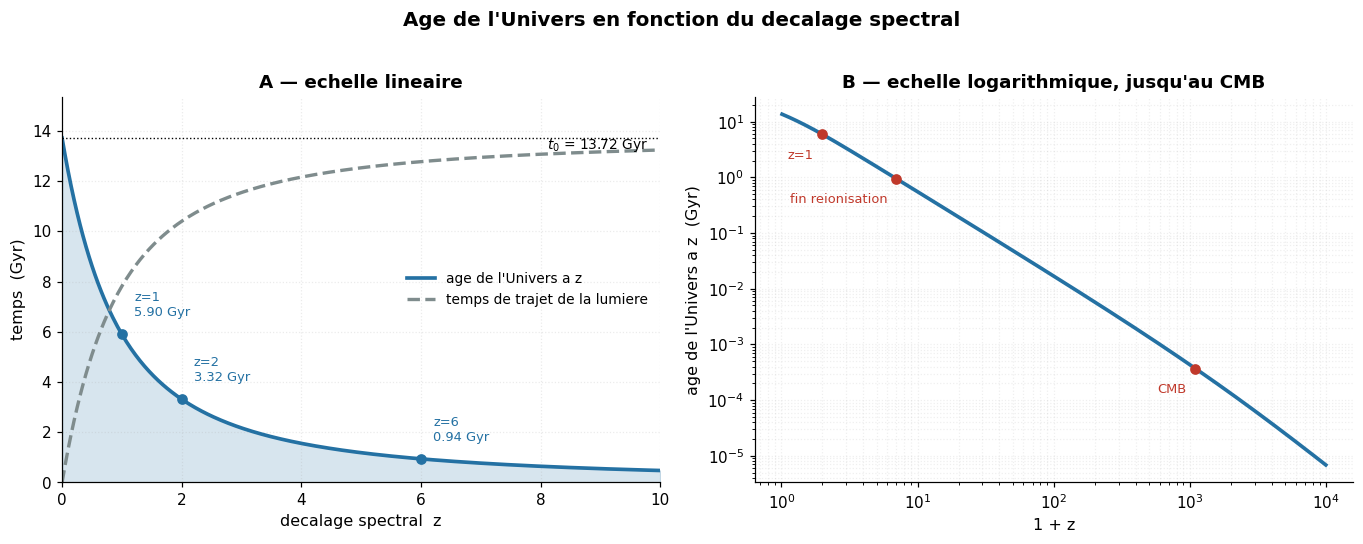

Age actuel de l'Univers : 13.721 Gyr
La moitie de l'age actuel etait atteinte vers z = 0.79


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

# ---------------- Panneau A : echelle lineaire, z de 0 a 10 -----------------
z = np.linspace(0, 10, 400)
d = serie_cosmo(z, **COSMO)
t0 = d["age_Gyr"].iloc[0]

ax1.fill_between(z, 0, d["zage_Gyr"], color=COUL["age"], alpha=.18)
ax1.plot(z, d["zage_Gyr"], color=COUL["age"], lw=2.4,
         label="age de l'Univers a z")
ax1.plot(z, d["DTT_Gyr"], color=COUL["tl"], lw=2.2, ls="--",
         label="temps de trajet de la lumiere")
ax1.axhline(t0, color="k", lw=.9, ls=":")
ax1.text(9.8, t0 - .45, f"$t_0$ = {t0:.2f} Gyr", ha="right", fontsize=9)

for zz in [1, 2, 6]:
    r = calcul_cosmo(zz, **COSMO)
    ax1.plot(zz, r["zage_Gyr"], "o", color=COUL["age"], ms=6, zorder=5)
    ax1.annotate(f"z={zz}\n{r['zage_Gyr']:.2f} Gyr",
                 (zz, r["zage_Gyr"]), textcoords="offset points",
                 xytext=(8, 12), fontsize=8.5, color=COUL["age"])

ax1.set_xlabel("decalage spectral  z")
ax1.set_ylabel("temps  (Gyr)")
ax1.set_title("A — echelle lineaire")
ax1.set_xlim(0, 10); ax1.set_ylim(0, t0 * 1.12)
ax1.legend(loc="center right", fontsize=9)

# ---------------- Panneau B : echelle log, jusqu'au CMB ---------------------
z2 = np.logspace(-2, 4, 500)
d2 = serie_cosmo(z2, **COSMO)

ax2.loglog(1 + z2, d2["zage_Gyr"], color=COUL["age"], lw=2.4)
ax2.set_xlabel("1 + z")
ax2.set_ylabel("age de l'Univers a z  (Gyr)")
ax2.set_title("B — echelle logarithmique, jusqu'au CMB")

for zz, nom in [(1, "z=1"), (6, "fin reionisation"), (1100, "CMB")]:
    r = calcul_cosmo(zz, **COSMO)
    ax2.plot(1 + zz, r["zage_Gyr"], "o", color=COUL["mat"], ms=6, zorder=5)
    ax2.annotate(nom, (1 + zz, r["zage_Gyr"]), textcoords="offset points",
                 xytext=(-6, -16), fontsize=8.5, ha="right", color=COUL["mat"])

ax2.grid(True, which="both", alpha=.2, ls=":")

fig.suptitle("Age de l'Univers en fonction du decalage spectral",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Age actuel de l'Univers : {t0:.3f} Gyr")
print(f"La moitie de l'age actuel etait atteinte vers z = "
      f"{np.interp(t0/2, d['zage_Gyr'][::-1], z[::-1]):.2f}")

**A lire sur cette figure**

- La courbe **s'ecrase tres vite** : a $z = 2$ l'Univers n'avait deja plus que
  ~3,3 Gyr, soit un quart de son age actuel. Les grands $z$ compriment enormement
  de temps cosmique dans peu de decalage spectral.
- Inversement, la **moitie recente** de l'histoire cosmique tient entre $z = 0$ et
  $z \approx 0{,}8$ : c'est le domaine ou les releves de SN Ia sont les plus contraignants.
- En panneau B, la courbe est presque une droite en log-log a grand $z$ : dans l'ere
  de matiere, $t \propto (1+z)^{-3/2}$, et dans l'ere de rayonnement $t \propto (1+z)^{-2}$.

## 9.2 Les trois distances sur une meme figure

C'est sans doute la figure la plus importante du notebook : elle montre qu'en
cosmologie **le mot « distance » n'a plus un sens unique**.

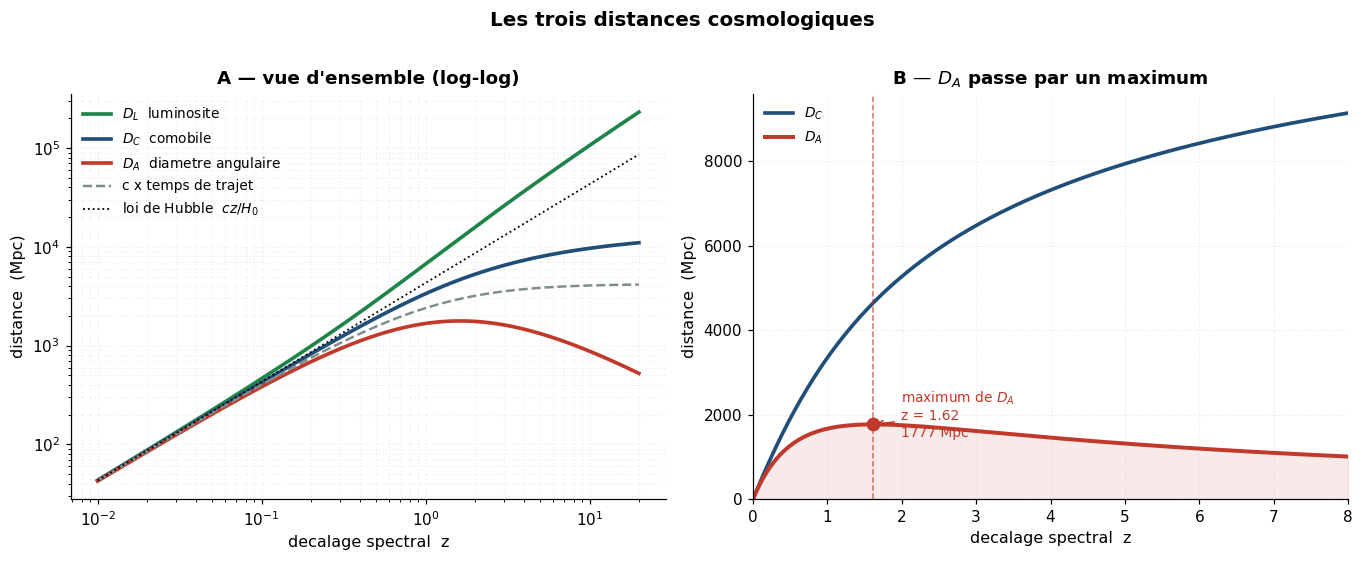

A z = 3 :  D_A =  1620.3 Mpc
           D_C =  6481.3 Mpc   (4.0 x D_A)
           D_L = 25924.3 Mpc   (16.0 x D_A)

Maximum de D_A a z = 1.617


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.0))

# ---------------- Panneau A : log-log, vue d'ensemble -----------------------
z = np.logspace(-2, np.log10(20), 500)
d = serie_cosmo(z, **COSMO)
DH = C_LUM / COSMO["H0"]

ax1.loglog(z, d["DL_Mpc"], color=COUL["DL"], lw=2.4, label=r"$D_L$  luminosite")
ax1.loglog(z, d["DCMR_Mpc"], color=COUL["DC"], lw=2.4, label=r"$D_C$  comobile")
ax1.loglog(z, d["DA_Mpc"], color=COUL["DA"], lw=2.4, label=r"$D_A$  diametre angulaire")
GLY_MPC = 306.6014  # 1 milliard d'annees-lumiere en Mpc
ax1.loglog(z, d["DTT_Gyr"] * GLY_MPC, color=COUL["tl"], lw=1.6, ls="--",
           label="c x temps de trajet")
ax1.loglog(z, DH * z, color="k", lw=1.2, ls=":", label=r"loi de Hubble  $cz/H_0$")

ax1.set_xlabel("decalage spectral  z")
ax1.set_ylabel("distance  (Mpc)")
ax1.set_title("A — vue d'ensemble (log-log)")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, which="both", alpha=.2, ls=":")

# ---------------- Panneau B : lineaire, le maximum de D_A -------------------
z2 = np.linspace(0.001, 8, 600)
d2 = serie_cosmo(z2, **COSMO)
imax = int(np.argmax(d2["DA_Mpc"].values))
z_max, DA_max = z2[imax], d2["DA_Mpc"].iloc[imax]

ax2.plot(z2, d2["DCMR_Mpc"], color=COUL["DC"], lw=2.4, label=r"$D_C$")
ax2.plot(z2, d2["DA_Mpc"], color=COUL["DA"], lw=2.6, label=r"$D_A$")
ax2.fill_between(z2, 0, d2["DA_Mpc"], color=COUL["DA"], alpha=.10)
ax2.axvline(z_max, color=COUL["DA"], lw=1, ls="--", alpha=.7)
ax2.plot(z_max, DA_max, "o", color=COUL["DA"], ms=8, zorder=5)
ax2.annotate(f"maximum de $D_A$\nz = {z_max:.2f}\n{DA_max:.0f} Mpc",
             (z_max, DA_max), textcoords="offset points", xytext=(18, -8),
             fontsize=9, color=COUL["DA"],
             arrowprops=dict(arrowstyle="->", color=COUL["DA"], lw=1))

ax2.set_xlabel("decalage spectral  z")
ax2.set_ylabel("distance  (Mpc)")
ax2.set_title(r"B — $D_A$ passe par un maximum")
ax2.set_xlim(0, 8); ax2.set_ylim(0, None)
ax2.legend(fontsize=9)

fig.suptitle("Les trois distances cosmologiques", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

r3 = calcul_cosmo(3.0, **COSMO)
print(f"A z = 3 :  D_A = {r3['DA_Mpc']:7.1f} Mpc")
print(f"           D_C = {r3['DCMR_Mpc']:7.1f} Mpc   ({r3['DCMR_Mpc']/r3['DA_Mpc']:.1f} x D_A)")
print(f"           D_L = {r3['DL_Mpc']:7.1f} Mpc   ({r3['DL_Mpc']/r3['DA_Mpc']:.1f} x D_A)")
print(f"\nMaximum de D_A a z = {z_max:.3f}")

**A lire sur cette figure**

- Les trois courbes **coincident quand $z \to 0$** : a faible distance, la notion de
  distance redevient unique et la loi de Hubble $cz/H_0$ est une bonne approximation.
  Elle decroche des $z \sim 0{,}2$.
- Elles divergent ensuite comme $(1+z)^2$ : a $z = 3$, $D_L$ vaut **16 fois** $D_A$.
  D'ou l'obligation absolue de preciser **de quelle distance on parle** dans un article.
- **$c \times$ temps de trajet** (pointille gris) reste toujours sous $D_C$, et sature
  vers 13,7 Gly. La distance comobile, elle, continue de croitre : un objet dont la
  lumiere a voyage 13 Gyr est aujourd'hui a plus de 30 Gly. Confondre les deux est
  l'erreur la plus frequente en vulgarisation.
- **Le maximum de $D_A$ vers $z \approx 1{,}6$** : au-dela, un objet de taille fixe
  place plus loin paraît **plus grand**. Ce n'est pas un artefact — c'est une
  consequence directe du fait que l'Univers etait plus petit quand la lumiere est partie.

## 9.3 Echelle spatiale : combien de kpc dans une seconde d'arc ?

C'est la grandeur la plus directement utile a l'observateur : elle convertit une
taille angulaire mesuree sur une image en taille physique.

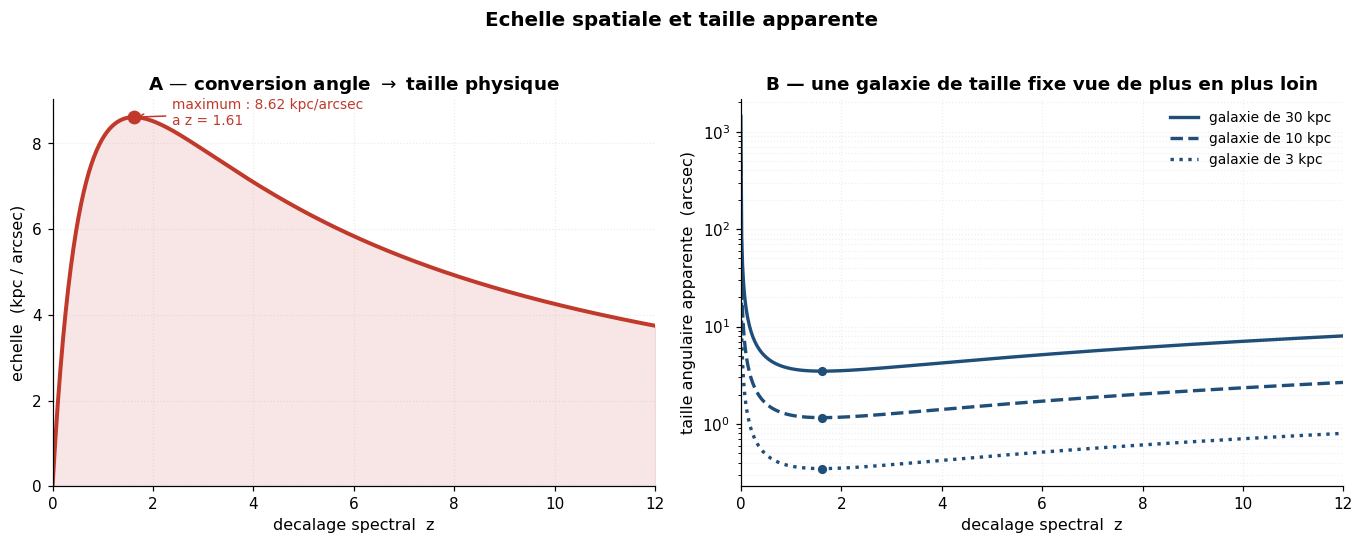

Echelle a quelques decalages caracteristiques :
  z =  0.01  ->   0.206 kpc/arcsec   (une galaxie de 10 kpc mesure 48.47 arcsec)
  z =  0.10  ->   1.857 kpc/arcsec   (une galaxie de 10 kpc mesure  5.39 arcsec)
  z =  0.50  ->   6.169 kpc/arcsec   (une galaxie de 10 kpc mesure  1.62 arcsec)
  z =  1.00  ->   8.122 kpc/arcsec   (une galaxie de 10 kpc mesure  1.23 arcsec)
  z =  1.60  ->   8.615 kpc/arcsec   (une galaxie de 10 kpc mesure  1.16 arcsec)
  z =  3.00  ->   7.855 kpc/arcsec   (une galaxie de 10 kpc mesure  1.27 arcsec)
  z =  6.00  ->   5.836 kpc/arcsec   (une galaxie de 10 kpc mesure  1.71 arcsec)
  z = 10.00  ->   4.255 kpc/arcsec   (une galaxie de 10 kpc mesure  2.35 arcsec)


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

z = np.linspace(0.001, 12, 700)
d = serie_cosmo(z, **COSMO)
i = int(np.argmax(d["kpc_arcsec"].values))

# ---------------- Panneau A : kpc / arcsec ----------------------------------
ax1.plot(z, d["kpc_arcsec"], color=COUL["DA"], lw=2.6)
ax1.fill_between(z, 0, d["kpc_arcsec"], color=COUL["DA"], alpha=.12)
ax1.plot(z[i], d["kpc_arcsec"].iloc[i], "o", color=COUL["DA"], ms=8, zorder=5)
ax1.annotate(f"maximum : {d['kpc_arcsec'].iloc[i]:.2f} kpc/arcsec\na z = {z[i]:.2f}",
             (z[i], d["kpc_arcsec"].iloc[i]), textcoords="offset points",
             xytext=(25, -5), fontsize=9, color=COUL["DA"],
             arrowprops=dict(arrowstyle="->", color=COUL["DA"], lw=1))
ax1.set_xlabel("decalage spectral  z")
ax1.set_ylabel("echelle  (kpc / arcsec)")
ax1.set_title("A — conversion angle $\\rightarrow$ taille physique")
ax1.set_xlim(0, 12); ax1.set_ylim(0, None)

# ---------------- Panneau B : taille apparente d'une galaxie ----------------
for taille_kpc, style in [(30, "-"), (10, "--"), (3, ":")]:
    theta = taille_kpc / d["kpc_arcsec"]
    ax2.plot(z, theta, ls=style, lw=2.2, color=COUL["DC"],
             label=f"galaxie de {taille_kpc} kpc")
    j = int(np.argmin(theta.values))
    ax2.plot(z[j], theta.iloc[j], "o", color=COUL["DC"], ms=5, zorder=5)

ax2.set_yscale("log")
ax2.set_xlabel("decalage spectral  z")
ax2.set_ylabel("taille angulaire apparente  (arcsec)")
ax2.set_title("B — une galaxie de taille fixe vue de plus en plus loin")
ax2.set_xlim(0, 12)
ax2.legend(fontsize=9)
ax2.grid(True, which="both", alpha=.2, ls=":")

fig.suptitle("Echelle spatiale et taille apparente", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Echelle a quelques decalages caracteristiques :")
for zz in [0.01, 0.1, 0.5, 1.0, 1.6, 3.0, 6.0, 10.0]:
    r = calcul_cosmo(zz, **COSMO)
    print(f"  z = {zz:5.2f}  ->  {r['kpc_arcsec']:6.3f} kpc/arcsec"
          f"   (une galaxie de 10 kpc mesure {10/r['kpc_arcsec']:5.2f} arcsec)")

**A lire sur cette figure**

- L'echelle plafonne vers **8,62 kpc/arcsec a $z \approx 1{,}62$** puis
  **redescend**. C'est la traduction directe du maximum de $D_A$ vu en 9.2.
- Panneau B : la taille apparente d'une galaxie de taille fixe passe par un
  **minimum** puis **remonte**. Une galaxie de 10 kpc a $z = 10$ paraît aussi grande
  qu'a $z \approx 0{,}6$ — mais elle est 200 fois plus faible en flux.
- **Ce n'est donc jamais la resolution angulaire qui limite l'observation des objets
  tres lointains, mais le flux.** C'est exactement le probleme que le JWST resout,
  et c'est pourquoi il travaille dans l'infrarouge : a $z = 10$, Lyman-$\alpha$
  (1216 Å) est decalee a 1,34 µm.

## 9.4 Le facteur d'echelle $a$

Deux facons de le regarder :

- **$a$ en fonction de $z$** : c'est une pure definition, $a = 1/(1+z)$, vraie dans
  **toutes** les cosmologies ;
- **$a$ en fonction du temps** : la, la cosmologie intervient pleinement. C'est la
  solution de l'equation de Friedmann.

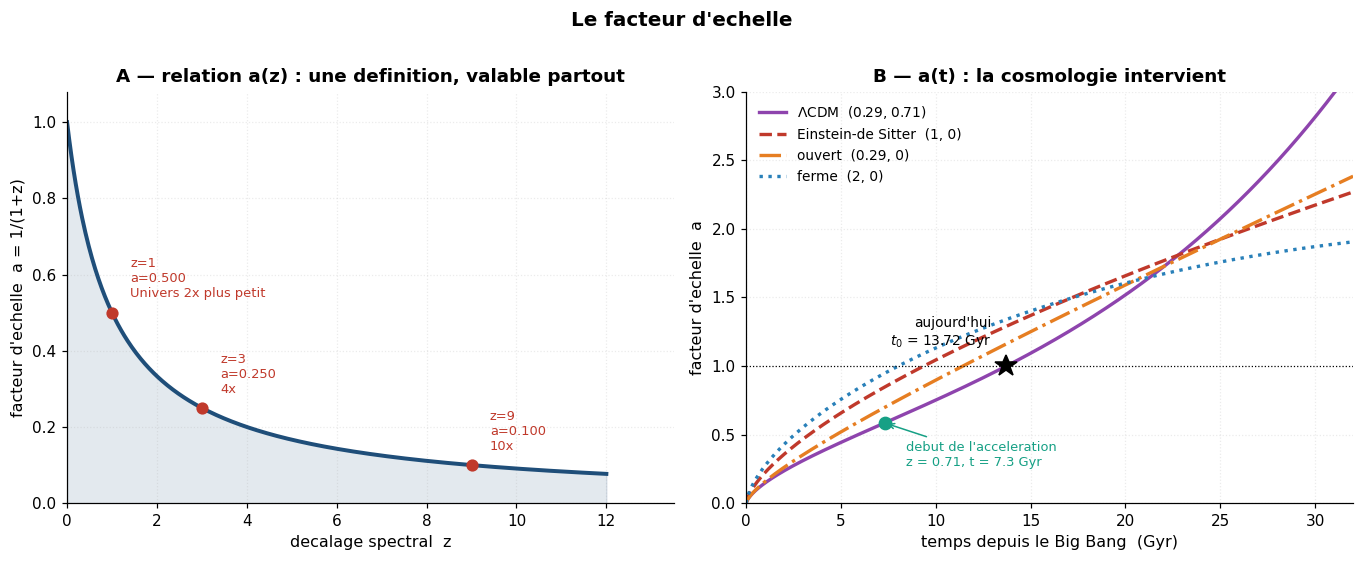

Verification a(t)=1  ->  t0 = 13.7207 Gyr
calcul_cosmo(z=0)    ->  t0 = 13.7208 Gyr

Debut de l'acceleration : z = 0.709, soit t = 7.29 Gyr
Egalite matiere-Lambda  : z = 0.357


In [14]:
def a_de_t(H0, WM, WV, WR=None, a_max=3.0, n=6000):
    # Integre t(a) = (1/H0) * Int_0^a da'/adot(a')  par trapezes cumules.
    # Renvoie (t_Gyr, a), tronque a la premiere valeur ou adot^2 <= 0
    # (univers en recontraction).
    h = H0 / 100.0
    if WR is None:
        WR = OMEGA_R_H2 / (h * h)
    WK = 1.0 - WM - WR - WV

    a = np.linspace(1e-7, a_max, n)
    E2 = WK + WM/a + WR/(a*a) + WV*a*a
    mauvais = np.where(E2 <= 0)[0]
    if len(mauvais):
        a, E2 = a[:mauvais[0]], E2[:mauvais[0]]

    f  = 1.0 / np.sqrt(E2)
    dt = 0.5 * (f[1:] + f[:-1]) * np.diff(a)
    t  = np.concatenate([[0.0], np.cumsum(dt)]) * (TYR / H0)
    return t, a


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.0))

# ---------------- Panneau A : a = 1/(1+z), definition -----------------------
z = np.linspace(0, 12, 500)
ax1.plot(z, 1/(1+z), color=COUL["DC"], lw=2.6)
ax1.fill_between(z, 0, 1/(1+z), color=COUL["DC"], alpha=.12)
for zz, txt in [(1, "Univers 2x plus petit"), (3, "4x"), (9, "10x")]:
    ax1.plot(zz, 1/(1+zz), "o", color=COUL["DA"], ms=7, zorder=5)
    ax1.annotate(f"z={zz}\na={1/(1+zz):.3f}\n{txt}", (zz, 1/(1+zz)),
                 textcoords="offset points", xytext=(12, 10), fontsize=8.5,
                 color=COUL["DA"])
ax1.set_xlabel("decalage spectral  z")
ax1.set_ylabel("facteur d'echelle  a = 1/(1+z)")
ax1.set_title("A — relation a(z) : une definition, valable partout")
ax1.set_xlim(0, 13.5); ax1.set_ylim(0, 1.08)

# ---------------- Panneau B : a(t), la vraie dynamique ----------------------
modeles = [
    ("$\\Lambda$CDM  (0.29, 0.71)", dict(H0=69.6, WM=0.286, WV=0.714), COUL["lam"], "-"),
    ("Einstein-de Sitter  (1, 0)",  dict(H0=69.6, WM=1.0,   WV=0.0),   COUL["mat"], "--"),
    ("ouvert  (0.29, 0)",           dict(H0=69.6, WM=0.286, WV=0.0),   COUL["cou"], "-."),
    ("ferme  (2, 0)",               dict(H0=69.6, WM=2.0,   WV=0.0),   COUL["ray"], ":"),
]
for nom, p, c, ls in modeles:
    t, a = a_de_t(**p)
    ax2.plot(t, a, color=c, lw=2.2, ls=ls, label=nom)

t_ref, a_ref = a_de_t(**COSMO)
t0 = np.interp(1.0, a_ref, t_ref)
ax2.axhline(1, color="k", lw=.8, ls=":")
ax2.plot(t0, 1.0, "*", color="k", ms=15, zorder=6)
ax2.annotate(f"aujourd'hui\n$t_0$ = {t0:.2f} Gyr", (t0, 1.0),
             textcoords="offset points", xytext=(-10, 14), fontsize=9, ha="right")

# Debut de l'acceleration : d2a/dt2 = 0
z_acc = (2*COSMO["WV"]/COSMO["WM"])**(1/3) - 1
a_acc = 1/(1+z_acc)
t_acc = np.interp(a_acc, a_ref, t_ref)
ax2.plot(t_acc, a_acc, "o", color=COUL["acc"], ms=8, zorder=6)
ax2.annotate(f"debut de l'acceleration\nz = {z_acc:.2f}, t = {t_acc:.1f} Gyr",
             (t_acc, a_acc), textcoords="offset points", xytext=(14, -28),
             fontsize=8.5, color=COUL["acc"],
             arrowprops=dict(arrowstyle="->", color=COUL["acc"], lw=1))

ax2.set_xlabel("temps depuis le Big Bang  (Gyr)")
ax2.set_ylabel("facteur d'echelle  a")
ax2.set_title("B — a(t) : la cosmologie intervient")
ax2.set_xlim(0, 32); ax2.set_ylim(0, 3)
ax2.legend(fontsize=9, loc="upper left")

fig.suptitle("Le facteur d'echelle", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Verification a(t)=1  ->  t0 = {t0:.4f} Gyr")
print(f"calcul_cosmo(z=0)    ->  t0 = {calcul_cosmo(1e-8, **COSMO)['age_Gyr']:.4f} Gyr")
print(f"\nDebut de l'acceleration : z = {z_acc:.3f}, soit t = {t_acc:.2f} Gyr")
print(f"Egalite matiere-Lambda  : z = {(COSMO['WV']/COSMO['WM'])**(1/3)-1:.3f}")

**A lire sur cette figure**

- Panneau A : la relation $a = 1/(1+z)$ **ne depend d'aucun parametre cosmologique**.
  Elle relie directement une observation ($z$) a une propriete geometrique de
  l'Univers (sa taille relative). Tout le reste — l'age, les distances — depend
  au contraire des $\Omega_i$.
- Panneau B : les quatre modeles partent tous du meme Big Bang mais divergent
  radicalement.
  - **$\Lambda$CDM** : concave (deceleration) jusqu'a $z \approx 0{,}7$, puis convexe —
    l'expansion **accelere**. C'est le point marque en vert.
  - **Einstein-de Sitter** : deceleration perpetuelle, $a \propto t^{2/3}$. Il donne
    un age de l'Univers trop court, incompatible avec l'age des amas globulaires —
    argument historique majeur contre ce modele.
  - **Ferme ($\Omega_M = 2$)** : la courbe **s'arrete** sur la figure. Ce n'est pas un
    bug : l'univers atteint un rayon maximal puis se recontracte, et l'integration
    n'est plus definie au-dela. Le code tronque proprement.
- La courbe $\Lambda$CDM est prolongee **au-dela d'aujourd'hui** : dans le futur,
  $a$ croit exponentiellement ($a \propto e^{H_0\sqrt{\Omega_\Lambda}\,t}$).

## 9.5 Les trois eres de l'Univers

Directement issue de la section 1.3 : chaque composant se dilue a son propre rythme,
donc le dominant change. Cette figure trace la **fraction** du budget energetique
detenue par chaque composant :

$$f_i(a) = \frac{\Omega_i\,a^{-3(1+w_i)}}{\sum_j \Omega_j\,a^{-3(1+w_j)}}$$

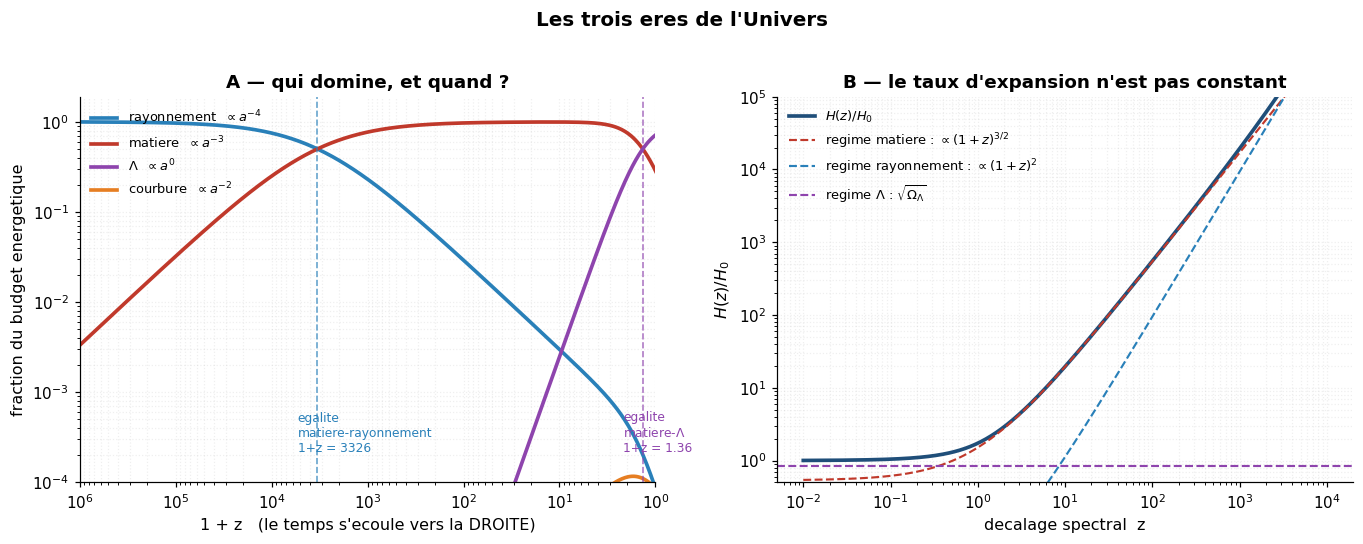

Omega_R = 8.598e-05   Omega_M = 0.286   Omega_L = 0.714   Omega_k = -8.60e-05
Egalite matiere-rayonnement : z = 3325  (t = 53 milliers d'annees)
Egalite matiere-Lambda      : z = 0.357  (t = 9.76 Gyr)


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))

H0, WM, WV = COSMO["H0"], COSMO["WM"], COSMO["WV"]
WR = OMEGA_R_H2 / (H0/100)**2
WK = 1 - WM - WR - WV

a = np.logspace(-6, 1, 900)
rho = {"ray": WR/a**4, "mat": WM/a**3, "lam": WV*np.ones_like(a)}
if abs(WK) > 1e-6:
    rho["cou"] = abs(WK)/a**2
tot = sum(rho.values())

noms = {"ray": "rayonnement  $\\propto a^{-4}$",
        "mat": "matiere  $\\propto a^{-3}$",
        "lam": "$\\Lambda$  $\\propto a^{0}$",
        "cou": "courbure  $\\propto a^{-2}$"}

for k, v in rho.items():
    ax1.loglog(1/a, v/tot, color=COUL[k], lw=2.4, label=noms[k])   # x = 1+z

z_eq  = WM/WR - 1
z_lam = (WV/WM)**(1/3) - 1
for zz, txt, c, yt in [(z_eq,  f"egalite\nmatiere-rayonnement\n1+z = {1+z_eq:.0f}",
                        COUL["ray"], 2.0e-4),
                       (z_lam, f"egalite\nmatiere-$\\Lambda$\n1+z = {1+z_lam:.2f}",
                        COUL["lam"], 2.0e-4)]:
    ax1.axvline(1 + zz, color=c, lw=1.1, ls="--", alpha=.7)
    ax1.text((1 + zz) * 1.6, yt, txt, fontsize=8, color=c, va="bottom")

ax1.set_xlabel("1 + z   (le temps s'ecoule vers la DROITE)")
ax1.set_ylabel("fraction du budget energetique")
ax1.set_title("A — qui domine, et quand ?")
ax1.set_xlim(1e6, 1.0); ax1.set_ylim(1e-4, 1.9)
ax1.legend(fontsize=8.5, loc="upper left")
ax1.grid(True, which="both", alpha=.2, ls=":")

# ---------------- Panneau B : H(z)/H0 ---------------------------------------
zz = np.logspace(-2, 4, 500)
E = np.sqrt(WM*(1+zz)**3 + WR*(1+zz)**4 + WK*(1+zz)**2 + WV)
ax2.loglog(zz, E, color=COUL["DC"], lw=2.4, label=r"$H(z)/H_0$")
ax2.loglog(zz, np.sqrt(WM)*(1+zz)**1.5, color=COUL["mat"], lw=1.4, ls="--",
           label=r"regime matiere : $\propto (1+z)^{3/2}$")
ax2.loglog(zz, np.sqrt(WR)*(1+zz)**2, color=COUL["ray"], lw=1.4, ls="--",
           label=r"regime rayonnement : $\propto (1+z)^{2}$")
ax2.axhline(np.sqrt(WV), color=COUL["lam"], lw=1.4, ls="--",
            label=r"regime $\Lambda$ : $\sqrt{\Omega_\Lambda}$")
ax2.set_xlabel("decalage spectral  z")
ax2.set_ylabel(r"$H(z) / H_0$")
ax2.set_title("B — le taux d'expansion n'est pas constant")
ax2.set_ylim(0.5, 1e5)
ax2.legend(fontsize=8.5, loc="upper left")
ax2.grid(True, which="both", alpha=.2, ls=":")

fig.suptitle("Les trois eres de l'Univers", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Omega_R = {WR:.3e}   Omega_M = {WM}   Omega_L = {WV}   Omega_k = {WK:+.2e}")
print(f"Egalite matiere-rayonnement : z = {z_eq:.0f}  "
      f"(t = {calcul_cosmo(z_eq, **COSMO)['zage_Gyr']*1e6:.0f} milliers d'annees)")
print(f"Egalite matiere-Lambda      : z = {z_lam:.3f}  "
      f"(t = {calcul_cosmo(z_lam, **COSMO)['zage_Gyr']:.2f} Gyr)")

**A lire sur cette figure**

- Le rayonnement, aujourd'hui a $10^{-4}$ du budget, **dominait** avant
  $z_{\text{eq}} \simeq 3300$. C'est pourquoi on ne peut pas le negliger quand on
  calcule l'age de l'Univers a la recombinaison.
- La domination de $\Lambda$ est **tres recente** : elle commence vers $z \approx 0{,}36$,
  soit il y a moins de 4 Gyr. Nous vivons dans une periode de transition — et c'est
  precisement ce qui rend le probleme de la coincidence cosmique intriguant.
- Panneau B : $H(z)$ suit trois lois de puissance successives. Le plateau a droite
  montre que $H$ tend vers la constante $H_0\sqrt{\Omega_\Lambda}$ dans le futur —
  l'expansion devient exponentielle.

## 9.6 Frise chronologique : evenements $\leftrightarrow$ decalage spectral

Chaque grand evenement de l'histoire cosmique correspond a un decalage spectral
precis. La frise ci-dessous les place sur un axe $\log(1+z)$ et affiche, pour
chacun, **l'age de l'Univers calcule par ce notebook**.

> **Precision honnete.** Les valeurs de $z$ des evenements ne sont **pas** predites
> par le calculateur : elles viennent de la physique atomique (recombinaison), de la
> physique stellaire (premieres etoiles) ou de l'observation (releves profonds).
> Ce que le notebook calcule, c'est **la date** correspondant a chaque $z$.
> Deux exceptions, entierement calculees : $z_{\text{eq}}$ et $z_{\text{acc}}$.
>
> La frise s'arrete a $z \sim 10^4$ : au-dela, l'hypothese $\Omega_R = \text{cte}$
> cesse d'etre valide (les degres de liberte relativistes changent). La nucleosynthese
> primordiale ($z \sim 4\times10^8$, $t \sim 3$ min) et l'inflation sont donc hors
> du domaine de validite de ce modele.

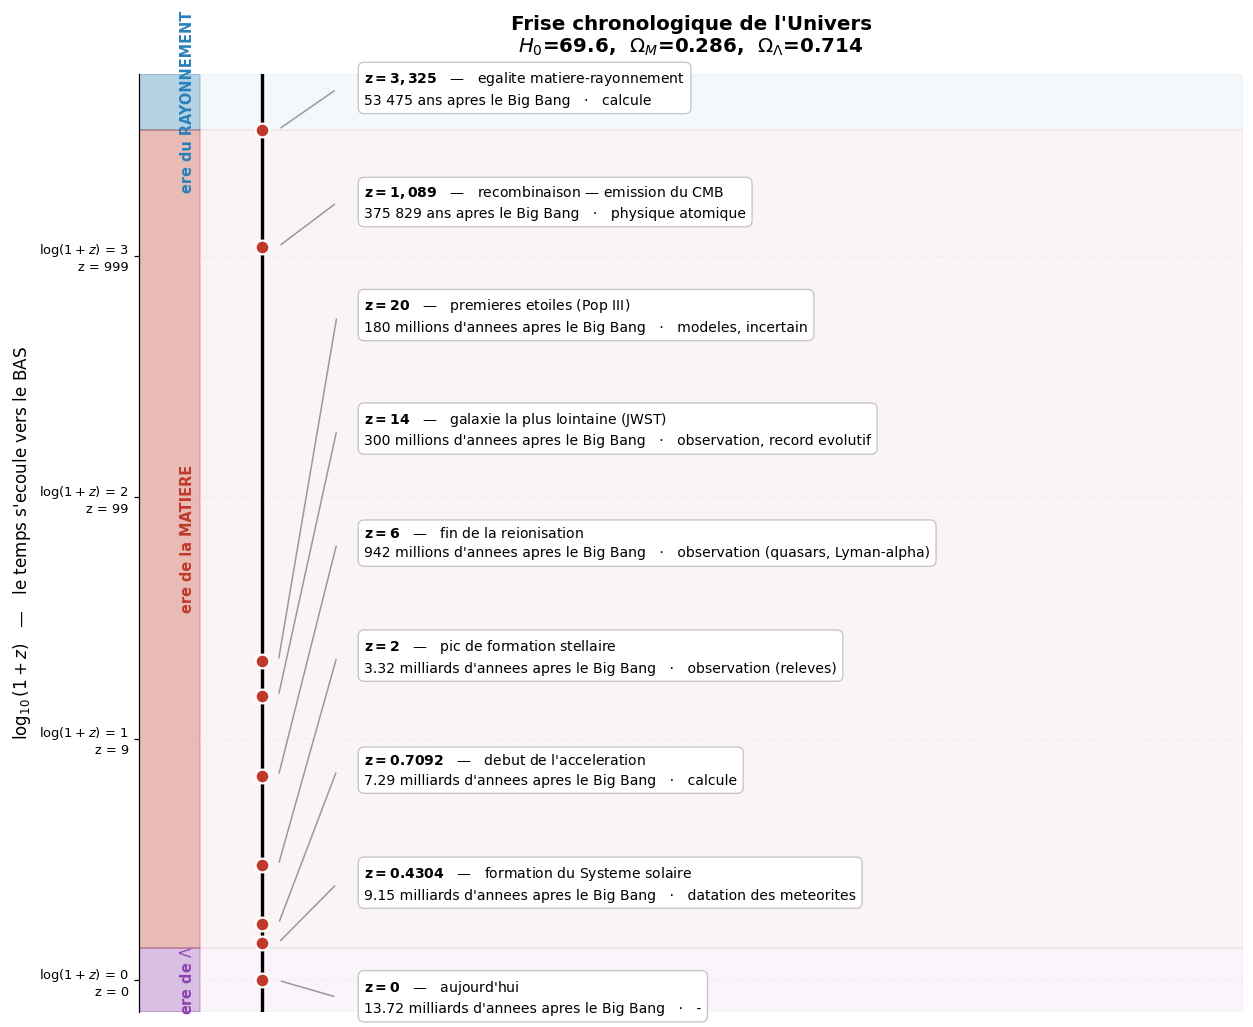

evenement                                       z    age (Gyr)  origine du z
-----------------------------------------------------------------------------------------------
egalite matiere-rayonnement                  3325      0.00005  calcule
recombinaison — emission du CMB              1089      0.00038  physique atomique
premieres etoiles (Pop III)                    20      0.18043  modeles, incertain
galaxie la plus lointaine (JWST)               14      0.29956  observation, record evolutif
fin de la reionisation                          6      0.94169  observation (quasars, Lyman-alpha)
pic de formation stellaire                      2      3.31634  observation (releves)
debut de l'acceleration                    0.7092      7.29361  calcule
formation du Systeme solaire               0.4304      9.15373  datation des meteorites
aujourd'hui                                     0     13.72075  -


In [17]:
# --- Evenements : (z, etiquette, origine de la valeur de z) -----------------
z_eq  = COSMO["WM"] / (OMEGA_R_H2 / (COSMO["H0"]/100)**2) - 1
z_acc = (2*COSMO["WV"]/COSMO["WM"])**(1/3) - 1
z_lam = (COSMO["WV"]/COSMO["WM"])**(1/3) - 1

# Formation du Systeme solaire : il y a 4.567 Gyr -> on inverse t(z)
t_ref, a_ref = a_de_t(**COSMO)
t0_ref = np.interp(1.0, a_ref, t_ref)
a_ss   = np.interp(t0_ref - 4.567, t_ref, a_ref)
z_ss   = 1/a_ss - 1

EVENEMENTS = [
    (z_eq,  "egalite matiere-rayonnement",        "calcule"),
    (1089.,  "recombinaison — emission du CMB",    "physique atomique"),
    (20.,    "premieres etoiles (Pop III)",        "modeles, incertain"),
    (14.,    "galaxie la plus lointaine (JWST)",   "observation, record evolutif"),
    (6.,     "fin de la reionisation",             "observation (quasars, Lyman-alpha)"),
    (2.,     "pic de formation stellaire",         "observation (releves)"),
    (z_acc,  "debut de l'acceleration",            "calcule"),
    (z_ss,   "formation du Systeme solaire",       "datation des meteorites"),
    (0.,     "aujourd'hui",                        "-"),
]

# --- Positions vraies (axe vertical) et ages calcules -----------------------
ys = np.array([np.log10(1 + zz) for zz, _, _ in EVENEMENTS])
ts = np.array([calcul_cosmo(max(zz, 1e-8), **COSMO)["zage_Gyr"]
               for zz, _, _ in EVENEMENTS])

def format_age(t):
    if t < 1e-3:   return f"{t*1e9:,.0f} ans".replace(",", " ")
    if t < 1:      return f"{t*1000:.0f} millions d'annees"
    return f"{t:.2f} milliards d'annees"

Y_HAUT, Y_BAS = 3.75, -0.13
fig, ax = plt.subplots(figsize=(11.5, 9.5))

# --- Bandes des trois eres ---------------------------------------------------
y_eq, y_lam = np.log10(1 + z_eq), np.log10(1 + z_lam)
for y0, y1, c, txt in [
        (y_eq,  Y_HAUT, COUL["ray"], "ere du RAYONNEMENT"),
        (y_lam, y_eq,   COUL["mat"], "ere de la MATIERE"),
        (Y_BAS, y_lam,  COUL["lam"], "ere de $\\Lambda$")]:
    ax.axhspan(y0, y1, xmin=0, xmax=0.055, color=c, alpha=.30)
    ax.axhspan(y0, y1, color=c, alpha=.05)
    ax.text(-0.055, (y0 + y1) / 2, txt, rotation=90, ha="center", va="center",
            fontsize=9.5, color=c, fontweight="bold")

# --- Axe principal -----------------------------------------------------------
ax.plot([0, 0], [Y_BAS, Y_HAUT], color="k", lw=2.2, zorder=3, solid_capstyle="round")

# --- Emplacements d'etiquettes regulierement espaces (evite tout chevauchement)
y_slots = np.linspace(Y_HAUT - 0.06, Y_BAS + 0.06, len(EVENEMENTS))

for (zz, lab, org), y_vrai, y_lab, t in zip(EVENEMENTS, ys, y_slots, ts):
    # ligne de rappel entre la position vraie et l'emplacement d'etiquette
    ax.annotate("", xy=(0.055, y_lab), xytext=(0.012, y_vrai),
                arrowprops=dict(arrowstyle="-", color="0.6", lw=1,
                                connectionstyle="arc3,rad=0.0"))
    ax.plot(0, y_vrai, "o", color=COUL["DA"], ms=9, zorder=5,
            markeredgecolor="white", markeredgewidth=1.4)
    ax.text(0.075, y_lab,
            f"$\\bf{{z = {zz:,.4g}}}$   —   {lab}\n"
            f"{format_age(t)} apres le Big Bang   ·   {org}",
            ha="left", va="center", fontsize=9.2, linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.42", fc="white", ec="0.78", lw=.9))

ax.set_ylim(Y_BAS, Y_HAUT)
ax.set_xlim(-0.09, 0.72)
ax.set_xticks([])
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([f"$\\log(1+z)$ = {k}\nz = {10**k - 1:,.0f}" for k in [0, 1, 2, 3]],
                   fontsize=8.5)
ax.set_ylabel(r"$\log_{10}(1+z)$   —   le temps s'ecoule vers le BAS", fontsize=11)
for s in ["top", "right", "bottom"]:
    ax.spines[s].set_visible(False)
ax.grid(True, axis="y", alpha=.18, ls=":")
ax.set_title("Frise chronologique de l'Univers\n"
             f"$H_0$={COSMO['H0']},  $\\Omega_M$={COSMO['WM']},  "
             f"$\\Omega_\\Lambda$={COSMO['WV']}",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

print(f"{'evenement':38s} {'z':>10s} {'age (Gyr)':>12s}  origine du z")
print("-"*95)
for (zz, lab, org), t in zip(EVENEMENTS, ts):
    print(f"{lab:38s} {zz:10.4g} {t:12.5f}  {org}")

**A lire sur cette frise**

- L'echelle logarithmique est indispensable : sans elle, tout ce qui precede
  $z \approx 10$ serait ecrase contre le bord gauche. Elle revele que **la moitie
  gauche de la frise ne represente que les 800 premiers millions d'annees**.
- La recombinaison ($z \simeq 1090$) et l'egalite matiere-rayonnement
  ($z \simeq 3300$) sont **proches en $z$** mais separees d'un facteur ~7 en temps.
- La formation du Systeme solaire ($z \approx 0{,}44$) et le debut de l'acceleration
  ($z \approx 0{,}67$) sont quasi contemporains — le Soleil s'est forme au moment ou
  l'Univers commencait a accelerer. Une coincidence, mais frappante.
- **Tout ce que l'astronomie optique observe** (galaxies, quasars, supernovae) tient
  dans le tiers droit de la frise.

---
# 10. Applications pratiques

Quelques fonctions utilitaires pour le travail courant sur des objets extragalactiques.

In [18]:
def taille_physique(theta_arcsec, z, **kw):
    # Taille physique (kpc) d'un objet de taille angulaire theta (arcsec) a z.
    return theta_arcsec * calcul_cosmo(z, **kw)["kpc_arcsec"]


def magnitude_absolue(m_apparente, z, **kw):
    # ATTENTION : ni correction K, ni extinction ne sont appliquees.
    return m_apparente - calcul_cosmo(z, **kw)["mu"]


def luminosite_L_sol(flux_erg_s_cm2, z, **kw):
    D_L_cm = calcul_cosmo(z, **kw)["DL_Mpc"] * MPC_M * 100
    return 4*np.pi * D_L_cm**2 * flux_erg_s_cm2 / L_SOL


def lambda_observee(lambda_repos_A, z):
    # Longueur d'onde observee (Angstroms) d'une raie emise a lambda_repos.
    return lambda_repos_A * (1 + z)


print(f"Galaxie de 2 arcsec a z=1 .......... {taille_physique(2., 1., **COSMO):.2f} kpc")
print(f"Galaxie de 2 arcsec a z=3 .......... {taille_physique(2., 3., **COSMO):.2f} kpc")
print(f"Quasar m=19 a z=2 .................. M = {magnitude_absolue(19., 2., **COSMO):.2f} mag")
print(f"SN Ia (M=-19.3) a z=0.5 ............ m = "
      f"{-19.3 + calcul_cosmo(0.5, **COSMO)['mu']:.2f} mag")
print(f"Flux 1e-13 erg/s/cm2 a z=0.1 ....... L = "
      f"{luminosite_L_sol(1e-13, 0.1, **COSMO):.3e} L_soleil")
print()
print("Ou tombent les raies usuelles selon z (Angstroms) :")
raies = {"Lyman-alpha": 1215.67, "[O II]": 3727.1, "H-beta": 4861.3,
         "[O III]": 5006.8, "H-alpha": 6562.8}
entete = "  " + "raie".ljust(13) + "".join(f"{'z='+str(z):>12s}" for z in [0, 1, 3, 7])
print(entete); print("  " + "-"*(len(entete)-2))
for nom, lam in raies.items():
    print("  " + nom.ljust(13) +
          "".join(f"{lambda_observee(lam, z):12.0f}" for z in [0, 1, 3, 7]))

Galaxie de 2 arcsec a z=1 .......... 16.24 kpc
Galaxie de 2 arcsec a z=3 .......... 15.71 kpc
Quasar m=19 a z=2 .................. M = -27.00 mag
SN Ia (M=-19.3) a z=0.5 ............ m = 22.98 mag
Flux 1e-13 erg/s/cm2 a z=0.1 ....... L = 6.713e+08 L_soleil

Ou tombent les raies usuelles selon z (Angstroms) :
  raie                  z=0         z=1         z=3         z=7
  -------------------------------------------------------------
  Lyman-alpha          1216        2431        4863        9725
  [O II]               3727        7454       14908       29817
  H-beta               4861        9723       19445       38890
  [O III]              5007       10014       20027       40054
  H-alpha              6563       13126       26251       52502


---
# 11. Fidelite au script original

| Aspect | `CC.py` (Wright) | Ce notebook |
|---|---|---|
| Physique | FLRW + $\Lambda$ + rayonnement | **identique** |
| Schema d'integration | point milieu, $n = 1000$ | **identique** (vectorise) |
| Traitement de la courbure | rapports $\sinh/\sin$ + DL | **identique** |
| Constantes | $c$, 977.8, 206.264806, 4.165e-5 | **identiques** |
| $\Omega_\Lambda$ par defaut | $1 - \Omega_M - \Omega_R$ | identique (`WV=None`) |
| $\Omega_R$ | toujours actif | desactivable (`WR=0`) — **ajout** |
| Entree $z > 100$ | interpretee comme une vitesse (km/s) | **non reproduit** |
| Sortie | texte | dictionnaire + texte + tableaux + figures |

**Une non-reproduction assumee.** Le script original contient :

```python
if float(sys.argv[1+verbose]) > 100:
    z = float(sys.argv[1+verbose]) / 299790.   # velocite -> redshift
```

C'est un raccourci de saisie en ligne de commande appliquant la relation **non
relativiste** $z = v/c$ (voir section 1.1). Correcte a quelques pour cent pres pour
$v \lesssim 10^4$ km/s, elle rend impossible tout calcul a $z > 100$ — donc le CMB.
On note aussi que la constante 299790 differe legerement de la valeur 299792,458
utilisee ailleurs dans le meme script.

**Verification croisee.** A $z = 3$ avec $H_0 = 69{,}6$, $\Omega_M = 0{,}286$,
$\Omega_\Lambda = 0{,}714$, ce notebook donne 13,721 / 2,171 / 11,549 Gyr et
6481,3 Mpc — valeurs identiques a celles publiees par le CosmoCalc de Wright.

---

# 12. Pour aller plus loin

- **Comparaison a `astropy.cosmology`** : gere les neutrinos massifs et $w(a)$.
  Permettrait de quantifier l'effet des approximations listees en introduction.
- **Fonction inverse** : de la distance mesuree vers $z$ (recherche de racine).
- **Diagramme $(\Omega_M, \Omega_\Lambda)$** avec les frontieres ouvert/ferme,
  acceleration/deceleration, et expansion eternelle / recontraction.
- **Diagramme de Hubble** avec de vraies donnees de SN Ia (Pantheon+).
- **Widgets `ipywidgets`** pour une mise a jour des figures en temps reel.
- **Horizons** : horizon des particules, horizon des evenements, sphere de Hubble —
  et le paradoxe apparent des objets a $z > 1{,}5$ qui s'eloignent plus vite que $c$
  tout en restant observables.